### Distillation

In [1]:
import subprocess
import os
from tqdm.notebook import tqdm

In [15]:
MODELS = ["dinov2_vitb"]
DATASET = "aqua20"
DATASET_PATH = f"/home/alex/internship/datasets/{DATASET}"
results = {m: {} for m in MODELS}
DISTILL_CONFIGS = {
    "dinov2_vitb": [{"syn_res": 196, "real_res": 196, "crop_res": 196, "train_crop_mode": "random", "augs_per_batch": 3, "num_eval": 2, "ipc": 1}],
}

In [17]:


# Aplatir tous les runs à faire
all_runs = [
    (model, cfg)
    for model, configs in DISTILL_CONFIGS.items()
    for cfg in configs
]

for model, config in tqdm(all_runs, desc="Distillation runs", unit="run"):
    run_name = f"{model}_distill_{config['syn_res']}_ipc{config['ipc']}_augs{config['augs_per_batch']}"
    
    tqdm.write(f"\n{'='*50}")
    tqdm.write(f"Distilling {model} | ipc={config['ipc']} | syn_res={config['syn_res']} | augs={config['augs_per_batch']}")
    tqdm.write(f"Run name: {run_name}")
    tqdm.write('='*50)

    env = os.environ.copy()
    env["DATASET"] = DATASET
    env["MODEL"] = model

    process = subprocess.Popen(
        [
            "./run.sh", "distill",
            f"--augs_per_batch={config['augs_per_batch']}",
            f"--syn_res={config['syn_res']}",
            f"--real_res={config['real_res']}",
            f"--crop_res={config['crop_res']}",
            f"--train_crop_mode={config['train_crop_mode']}",
            f"--ipc={config['ipc']}",
            f"--run_name={run_name}",
            f"--data_root={DATASET_PATH}"
        ],
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        cwd="/home/alex/internship/GradientDistillation"
    )

    for line in process.stdout:
        tqdm.write(line, end="")

    process.wait()
    tqdm.write(f"\nReturn code: {process.returncode}")

Distillation runs:   0%|          | 0/1 [00:00<?, ?run/s]


Distilling dinov2_vitb | ipc=1 | syn_res=196 | augs=3
Run name: dinov2_vitb_distill_196_ipc1_augs3
/home/alex/internship/GradientDistillation/.venv/lib/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/home/alex/internship/GradientDistillation/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
{'aug_mode': 'standard',
 'augs_per_batch': 3,
 'checkpoint_it': 100,
 'crop_res': 196,
 'data_root': '/home/alex/internship/datasets/aqua20',
 'dataset': 'aqua20',
 'decorrelate_color': True,
 'devic

### Visualization

Shape: torch.Size([20, 3, 196, 196])


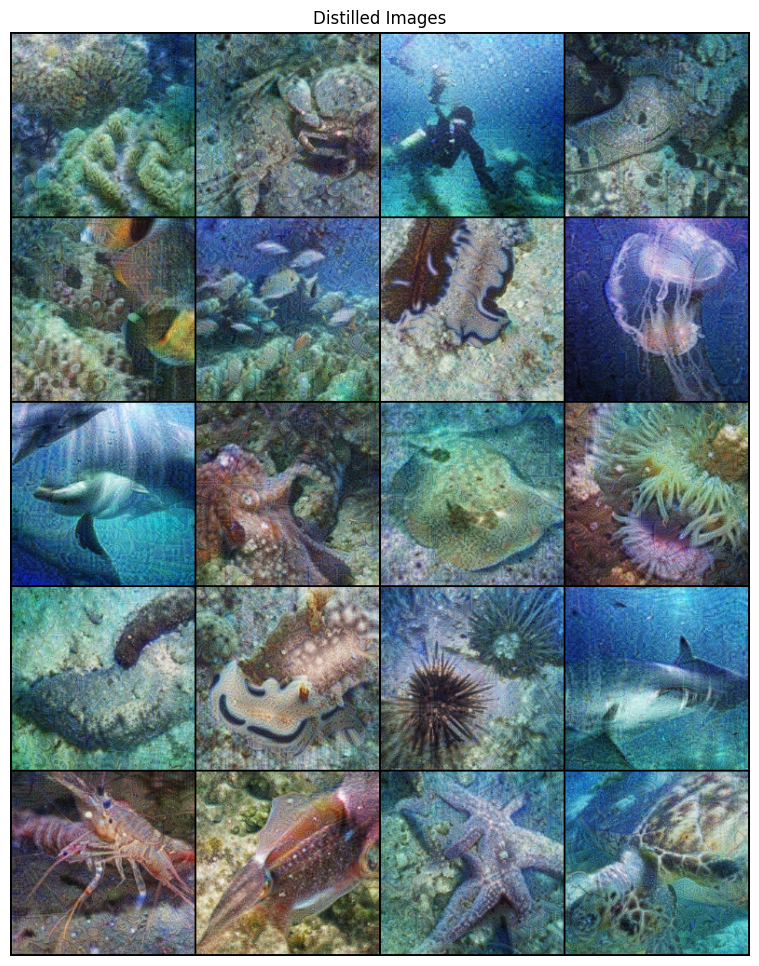

In [19]:
import torch
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Load
run_name = "dinov2_vitb_distill_196_ipc1_augs3"
data = torch.load(f"/home/alex/internship/GradientDistillation/logged_files/distillation/aqua20/dinov2_vitb/{run_name}/data.pth", weights_only=False)

images = data["images"]  # (N, C, H, W)
print(f"Shape: {images.shape}")

# Display grid
grid = vutils.make_grid(images, nrow=4, padding=2)
plt.figure(figsize=(12, 12))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Distilled Images")
plt.show()

### Benchmark

In [3]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score
import time
from tqdm.notebook import tqdm
from torch.utils.data import Subset
from collections import defaultdict
import random

In [4]:
DATA_ROOT = "/home/alex/internship/datasets/aqua20/data/aqua20"
DISTILLED_PTH = "../logged_files/distillation/aqua20/dinov2_vitb/dinov2_vitb_distill_196_ipc1_augs3/data.pth"
NUM_CLASSES = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESOLUTION = 196

In [5]:
transform = transforms.Compose([
    transforms.Resize(RESOLUTION),
    transforms.CenterCrop(RESOLUTION),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [6]:
backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
backbone.eval()
for p in backbone.parameters():
    p.requires_grad = False
backbone = backbone.to(DEVICE)

Using cache found in /home/alex/.cache/torch/hub/facebookresearch_dinov2_main
/home/alex/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/alex/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/alex/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [ ]:
def extract_features(loader, desc="Extracting features"):
    all_feats, all_labels = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc=desc, leave=False):
            all_feats.append(backbone(x.to(DEVICE)).cpu())
            all_labels.append(y)
    return torch.cat(all_feats), torch.cat(all_labels)


def train_linear_probe(train_feats, train_labels, test_feats, test_labels,
                       epochs=50, lr=1e-3, eval_every=10):
    head = nn.Linear(768, NUM_CLASSES).to(DEVICE)
    optimizer = torch.optim.Adam(head.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # Loaders sur features précalculées — tout en RAM, très rapide
    train_feat_loader = DataLoader(
        TensorDataset(train_feats, train_labels), batch_size=256, shuffle=True
    )
    test_feat_loader = DataLoader(
        TensorDataset(test_feats, test_labels), batch_size=256, shuffle=False
    )

    for epoch in tqdm(range(epochs), desc="Training"):
        head.train()
        total_loss, correct, total = 0.0, 0, 0

        for feats, y in train_feat_loader:
            feats, y = feats.to(DEVICE), y.to(DEVICE)
            logits = head(feats)
            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(y)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += len(y)

        if (epoch + 1) % eval_every == 0 or epoch == epochs - 1:
            head.eval()
            all_preds, all_labels_val = [], []
            with torch.no_grad():
                for feats, y in test_feat_loader:
                    feats = feats.to(DEVICE)
                    preds = head(feats).argmax(dim=1).cpu()
                    all_preds.append(preds)
                    all_labels_val.append(y)

            all_preds      = torch.cat(all_preds).numpy()
            all_labels_val = torch.cat(all_labels_val).numpy()

            f1_macro = f1_score(all_labels_val, all_preds, average="macro")
            f1_weighted = f1_score(all_labels_val, all_preds, average="weighted")

            tqdm.write(
                f"Epoch {epoch+1:>3}/{epochs} | "
                f"Loss: {total_loss/total:.4f} | "
                f"Train Acc: {correct/total*100:.1f}% | "
                f"F1 Macro: {f1_macro*100:.1f}% | "
                f"F1 Weighted: {f1_weighted*100:.1f}%"
            )

    return head

In [8]:
full_train = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=transform)
test_ds    = datasets.ImageFolder(f"{DATA_ROOT}/test",  transform=transform)

full_loader = DataLoader(full_train, batch_size=64, shuffle=True, num_workers=4)
test_loader = DataLoader(test_ds,   batch_size=64, shuffle=False, num_workers=4)

In [9]:
distilled = torch.load(DISTILLED_PTH, map_location=DEVICE)
# distilled est un tensor (N, C, H, W) ou un dict selon ton format
# adapte selon ce que run.sh sauvegarde
print(f"Distilled data keys: {distilled.keys()}")
images_d = distilled["images"].to(DEVICE)   # shape: (20, 3, 196, 196)
labels_d = distilled["labels"].to(DEVICE)
print(labels_d)
from torch.utils.data import TensorDataset
distill_loader = DataLoader(
    TensorDataset(images_d.cpu(), labels_d.cpu()),
    batch_size=20, shuffle=True
)

Distilled data keys: dict_keys(['images', 'labels'])
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19], device='cuda:0')


In [10]:
ipc = len(images_d) // len(full_train.classes)
rng = random.Random(123)

class_to_indices = defaultdict(list)
for idx, (_, label) in enumerate(full_train.samples):
    class_to_indices[label].append(idx)



stratified_indices = []
for label, indices in class_to_indices.items():
    stratified_indices.extend(rng.sample(indices, ipc))

random_subset = Subset(full_train, stratified_indices)

random_loader = DataLoader(
    random_subset,
    batch_size=len(stratified_indices),
    shuffle=True,
    num_workers=4,
)

In [11]:
print("Extracting features...")
test_feats,    test_labels    = extract_features(test_loader,    "Test")


Extracting features...


Test:   0%|          | 0/26 [00:00<?, ?it/s]

#### Full data


In [17]:
print("\nTraining on full data...")
start_time = time.time()
full_feats,    full_labels    = extract_features(full_loader,    "Full train")
head_full = train_linear_probe(full_feats, full_labels, test_feats, test_labels,
                                epochs=50, eval_every=10)
print(f"Training time: {time.time() - start_time:.6f} seconds")


Training on full data...


Full train:   0%|          | 0/103 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch  10/50 | Loss: 0.1461 | Train Acc: 95.4% | F1 Macro: 89.3% | F1 Weighted: 90.3%
Epoch  20/50 | Loss: 0.1047 | Train Acc: 96.6% | F1 Macro: 88.9% | F1 Weighted: 90.4%
Epoch  30/50 | Loss: 0.0828 | Train Acc: 97.4% | F1 Macro: 89.5% | F1 Weighted: 90.8%
Epoch  40/50 | Loss: 0.0683 | Train Acc: 98.0% | F1 Macro: 89.1% | F1 Weighted: 90.2%
Epoch  50/50 | Loss: 0.0602 | Train Acc: 98.2% | F1 Macro: 89.2% | F1 Weighted: 90.2%
Training time: 30.149740 seconds


#### Distilled data


In [20]:
print("\nTraining on distilled data...")
start_time = time.time()
distill_feats, distill_labels = extract_features(distill_loader, "Distilled")
head_dist = train_linear_probe(distill_feats, distill_labels, test_feats, test_labels,
                                epochs=50, eval_every=20)
print(f"Training time: {time.time() - start_time:.6f} seconds")


Training on distilled data...


Distilled:   0%|          | 0/1 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch  20/50 | Loss: 0.0017 | Train Acc: 100.0% | F1 Macro: 70.7% | F1 Weighted: 72.2%
Epoch  40/50 | Loss: 0.0004 | Train Acc: 100.0% | F1 Macro: 72.6% | F1 Weighted: 73.7%
Epoch  50/50 | Loss: 0.0003 | Train Acc: 100.0% | F1 Macro: 72.2% | F1 Weighted: 73.7%
Training time: 0.568795 seconds


#### Random Data


In [12]:
print("\nTraining on random data...")
start_time = time.time()
random_feats, random_labels = extract_features(random_loader, "Distilled")
head_dist = train_linear_probe(random_feats, random_labels, test_feats, test_labels,
                                epochs=50, eval_every=20)
print(f"Training time: {time.time() - start_time:.6f} seconds")


Training on random data...


Distilled:   0%|          | 0/1 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch  20/50 | Loss: 0.0006 | Train Acc: 100.0% | F1 Macro: 50.3% | F1 Weighted: 53.1%
Epoch  40/50 | Loss: 0.0001 | Train Acc: 100.0% | F1 Macro: 52.0% | F1 Weighted: 53.0%
Epoch  50/50 | Loss: 0.0001 | Train Acc: 100.0% | F1 Macro: 52.1% | F1 Weighted: 53.0%
Training time: 1.345128 seconds


#### No pretraining (random head)

In [13]:
def evaluate_random_head(test_feats, test_labels, feat_dim=768):
    head = nn.Linear(feat_dim, NUM_CLASSES).to(DEVICE)
    head.eval()

    test_feat_loader = DataLoader(
        TensorDataset(test_feats, test_labels), batch_size=256, shuffle=False
    )

    all_preds, all_labels_val = [], []
    with torch.no_grad():
        for feats, y in test_feat_loader:
            feats = feats.to(DEVICE)
            preds = head(feats).argmax(dim=1).cpu()
            all_preds.append(preds)
            all_labels_val.append(y)

    all_preds      = torch.cat(all_preds).numpy()
    all_labels_val = torch.cat(all_labels_val).numpy()

    acc         = (all_preds == all_labels_val).mean()
    f1_macro    = f1_score(all_labels_val, all_preds, average="macro")
    f1_weighted = f1_score(all_labels_val, all_preds, average="weighted")

    print(
        f"Random head baseline | "
        f"Test Acc: {acc*100:.1f}% | "
        f"F1 Macro: {f1_macro*100:.1f}% | "
        f"F1 Weighted: {f1_weighted*100:.1f}%"
    )
    return head

print("\nBaseline: random (untrained) head...")
evaluate_random_head(test_feats, test_labels)


Baseline: random (untrained) head...
Random head baseline | Test Acc: 1.8% | F1 Macro: 1.7% | F1 Weighted: 2.0%


Linear(in_features=768, out_features=20, bias=True)